Loading data...
Computing climatologies...
Applying native model land mask BEFORE regridding...
Regridding Model to Obs (Conservative)...


/nbhome/Soelem.Bhuiyan/gfdl/lib/python3.12/site-packages/xesmf/frontend.py:96: UserWarning: Variables {'lon_bnds'} not found in object but are referred to in the CF attributes.
  lon_bnds = ds.cf.get_bounds('longitude')
/nbhome/Soelem.Bhuiyan/gfdl/lib/python3.12/site-packages/xesmf/backend.py:57: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


Isolating tropical oceans and applying common mask...
Calculating spherically-weighted statistics...
Stats Check -> Bias Ave: -0.156, RMSD: 0.636, Corr: 0.94
Plotting mathematically honest (unfiltered) data...
Done! Saved as t_surf_final_replica.png!


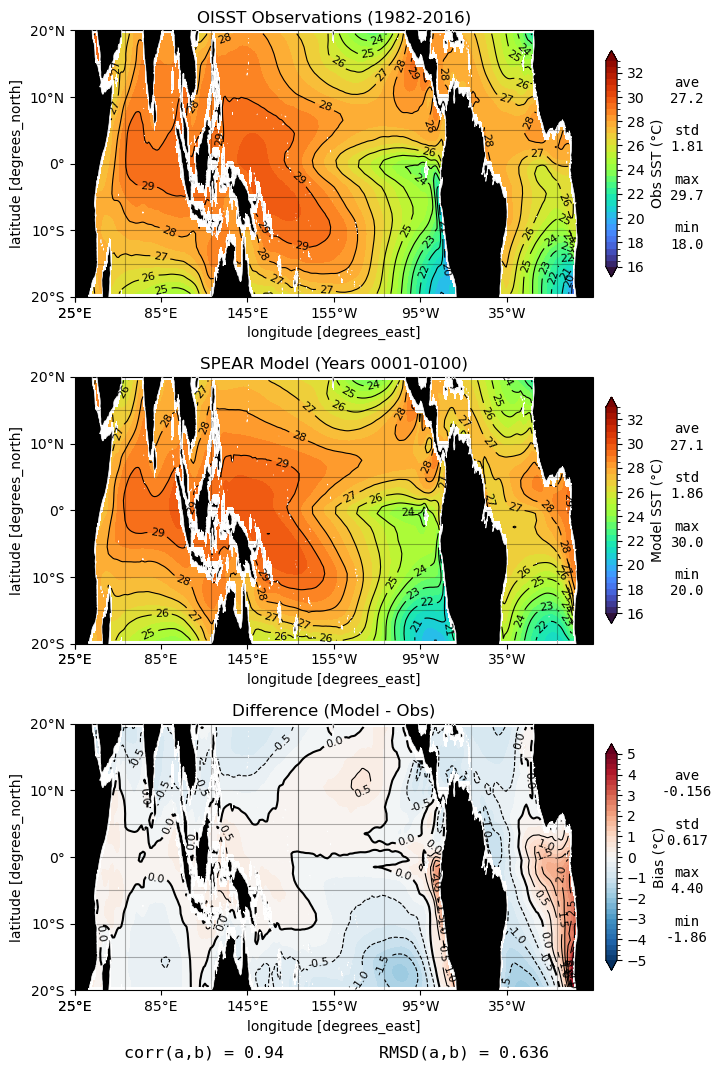

In [ ]:
import xarray as xr
import numpy as np
import xesmf as xe
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import time

# Safely silence the xarray warnings about future updates
xr.set_options(use_new_combine_kwarg_defaults=True)

# Start the master stopwatch
total_start = time.perf_counter()

# ==========================================
# 1. LOAD DATA
# ==========================================
print("\n[1/7] Loading data...")
t0 = time.perf_counter()

model_path = "/archive/wfc/SPEAR/SPEAR_HI_8/SPEAR_c384_OM4p08_Control_1990_A13/pp/atmos/ts/monthly/10yr/atmos.*.t_surf.nc"
obs_path = "/home/atw/data/reynolds/v2/noaa.oisst.v2/sst_janstart.nc"
static_path = "/archive/wfc/SPEAR/SPEAR_HI_8/SPEAR_c384_OM4p08_Control_1990_A13/pp/atmos/atmos.static.nc"

ds_model = xr.open_mfdataset(model_path, combine='by_coords')
ds_obs = xr.open_dataset(obs_path)

# Explicitly slice the first 100 years (1200 months)
ds_model = ds_model.isel(time=slice(0, 1200))

print(f"⏱️  Step 1 Took: {time.perf_counter() - t0:.2f} seconds")

# ==========================================
# 2. The Climatology
# ==========================================
print("\n[2/7] Computing climatologies...")
t0 = time.perf_counter()

model_clim = ds_model['t_surf'].mean(dim='time', keep_attrs=True)
model_clim = model_clim - 273.15  # Convert Kelvin to Celsius
obs_clim = ds_obs['SST'].sel(time=slice('1982', '2016')).mean(dim='time', keep_attrs=True)

# Use xarray
model_clim = model_clim.compute()
obs_clim = obs_clim.compute()

print(f"⏱️  Step 2 Took: {time.perf_counter() - t0:.2f} seconds")

# ==========================================
# 3. NATIVE LAND MASK
# ==========================================
print("\n[3/7] Applying native model land mask...")
t0 = time.perf_counter()

try:
    ds_static = xr.open_dataset(static_path)
    if 'land_mask' in ds_static:
        model_clim = model_clim.where(ds_static['land_mask'] < 0.5)
    elif 'frac_ocean' in ds_static:
        model_clim = model_clim.where(ds_static['frac_ocean'] > 0.5)
    else:
        print("WARNING: 'land_mask' or 'frac_ocean' not found in static file. Land bleed may occur.")
except FileNotFoundError:
    print(f"WARNING: Could not find {static_path}. Land bleed will occur!")

print(f"⏱️  Step 3 Took: {time.perf_counter() - t0:.2f} seconds")

# ==========================================
# 4. REGRIDDING (use Bilinear/Conservative as appropriate as argument)
# ==========================================
print("\n[4/7] Regridding Model to Obs (Bilinear)...")
t0 = time.perf_counter()

regridder = xe.Regridder(model_clim, obs_clim, 'bilinear', periodic=True)
model_regridded = regridder(model_clim)

print(f"⏱️  Step 4 Took: {time.perf_counter() - t0:.2f} seconds")

# ==========================================
# 5. SPATIAL SLICING & MASKING
# ==========================================
print("\n[5/7] Isolating tropical oceans and applying common mask...")
t0 = time.perf_counter()

model_tropics = model_regridded.sel(lat=slice(-20, 20))
obs_tropics = obs_clim.sel(lat=slice(-20, 20))

common_mask = model_tropics.notnull() & obs_tropics.notnull()

a_var = obs_tropics.where(common_mask)   # Ferret Variable A (Obs)
b_var = model_tropics.where(common_mask) # Ferret Variable B (Model)
bma_var = b_var - a_var                  # Ferret Bias (Model minus Obs)

print(f"⏱️  Step 5 Took: {time.perf_counter() - t0:.2f} seconds")

# ==========================================
# 6. SPHERICAL STATISTICS (Cosine Weighting)
# ==========================================
print("\n[6/7] Calculating spherically-weighted statistics...")
t0 = time.perf_counter()

weights = np.cos(np.deg2rad(a_var.lat))
weights.name = "weights"

def get_weighted_stats(da, w):
    daw = da.weighted(w)
    ave = daw.mean(skipna=True).values
    std = daw.std(skipna=True).values
    vmax = da.max(skipna=True).values
    vmin = da.min(skipna=True).values
    return ave, std, vmax, vmin

a_ave, a_std, a_max, a_min = get_weighted_stats(a_var, weights)
b_ave, b_std, b_max, b_min = get_weighted_stats(b_var, weights)
bma_ave, bma_std, bma_max, bma_min = get_weighted_stats(bma_var, weights)

ab_rmsd = np.sqrt(((bma_var)**2).weighted(weights).mean(skipna=True)).values
covar = ((b_var - b_ave) * (a_var - a_ave)).weighted(weights).mean(skipna=True)
ab_corr = (covar / (b_var.weighted(weights).std(skipna=True) * a_var.weighted(weights).std(skipna=True))).values

print(f"Stats Check -> Bias Ave: {bma_ave:.3f}, RMSD: {ab_rmsd:.3f}, Corr: {ab_corr:.2f}")
print(f"⏱️  Step 6 Took: {time.perf_counter() - t0:.2f} seconds")

# ==========================================
# 7. EXECUTION & PLOTTING 
# ==========================================
print("\n[7/7] Plotting mathematically honest (unfiltered) data...")
t0 = time.perf_counter()

fig, axes = plt.subplots(3, 1, figsize=(10, 12), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=205)})

plt.subplots_adjust(right=0.75, bottom=0.08, hspace=0.3)

sst_shade_levels = np.arange(16, 33.5, 0.5)
sst_line_levels = np.arange(16, 34, 1.0)
bias_shade_levels = np.arange(-5, 5.25, 0.25)
bias_line_levels = np.arange(-5, 5.5, 0.5)

for ax in axes:
    ax.set_extent([25, 385, -20, 20], crs=ccrs.PlateCarree())
    ax.set_aspect('auto', adjustable='box')
    ax.add_feature(cfeature.LAND, facecolor='black', zorder=2)
    ax.coastlines(color='white', linewidth=0.5, zorder=3)
    ax.set_xticks(np.arange(25, 386, 60), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-20, 21, 10), crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.gridlines(color='black', linestyle='-', alpha=0.3, zorder=4)

# --- Panel 1: Obs ---
cs1 = a_var.plot.contourf(ax=axes[0], transform=ccrs.PlateCarree(), levels=sst_shade_levels, cmap='turbo', add_colorbar=False, extend='both')
line1 = a_var.plot.contour(ax=axes[0], transform=ccrs.PlateCarree(), levels=sst_line_levels, colors='black', linewidths=0.8)
axes[0].clabel(line1, inline=True, fontsize=8, fmt='%1.0f')
axes[0].set_title("OISST Observations (1982-2016)")
fig.colorbar(cs1, ax=axes[0], label='Obs SST (°C)', pad=0.02, shrink=0.85)

axes[0].text(1.18, 0.5, f"ave\n{a_ave:.1f}\n\nstd\n{a_std:.2f}\n\nmax\n{a_max:.1f}\n\nmin\n{a_min:.1f}", 
             transform=axes[0].transAxes, va='center', ha='center', fontsize=10, family='monospace', clip_on=False)

# --- Panel 2: Model ---
cs2 = b_var.plot.contourf(ax=axes[1], transform=ccrs.PlateCarree(), levels=sst_shade_levels, cmap='turbo', add_colorbar=False, extend='both')
line2 = b_var.plot.contour(ax=axes[1], transform=ccrs.PlateCarree(), levels=sst_line_levels, colors='black', linewidths=0.8)
axes[1].clabel(line2, inline=True, fontsize=8, fmt='%1.0f')
axes[1].set_title("SPEAR Model (Years 0001-0100)")
fig.colorbar(cs2, ax=axes[1], label='Model SST (°C)', pad=0.02, shrink=0.85)

axes[1].text(1.18, 0.5, f"ave\n{b_ave:.1f}\n\nstd\n{b_std:.2f}\n\nmax\n{b_max:.1f}\n\nmin\n{b_min:.1f}", 
             transform=axes[1].transAxes, va='center', ha='center', fontsize=10, family='monospace', clip_on=False)

# --- Panel 3: Bias ---
cs3 = bma_var.plot.contourf(ax=axes[2], transform=ccrs.PlateCarree(), levels=bias_shade_levels, cmap='RdBu_r', add_colorbar=False, extend='both')
line_widths = [1.5 if lev == 0 else 0.8 for lev in bias_line_levels]
line3 = bma_var.plot.contour(ax=axes[2], transform=ccrs.PlateCarree(), levels=bias_line_levels, colors='black', linewidths=line_widths)
axes[2].clabel(line3, inline=True, fontsize=8, fmt='%1.1f')
axes[2].set_title("Difference (Model - Obs)")
fig.colorbar(cs3, ax=axes[2], label='Bias (°C)', pad=0.02, shrink=0.85, ticks=np.arange(-5, 6, 1))

axes[2].text(1.18, 0.5, f"ave\n{bma_ave:.3f}\n\nstd\n{bma_std:.3f}\n\nmax\n{bma_max:.2f}\n\nmin\n{bma_min:.2f}", 
             transform=axes[2].transAxes, va='center', ha='center', fontsize=10, family='monospace', clip_on=False)

axes[2].text(0.25, -0.25, f"corr(a,b) = {ab_corr:.2f}", transform=axes[2].transAxes, ha='center', fontsize=12, family='monospace', clip_on=False)
axes[2].text(0.75, -0.25, f"RMSD(a,b) = {ab_rmsd:.3f}", transform=axes[2].transAxes, ha='center', fontsize=12, family='monospace', clip_on=False)

plt.show()
plt.savefig("t_surf_final_replica.png", dpi=600, bbox_inches='tight')
print(f"⏱️  Step 7 Took: {time.perf_counter() - t0:.2f} seconds")

# Stop the stopwatch
print(f"\n✅ TOTAL PIPELINE TIME: {time.perf_counter() - total_start:.2f} seconds")